In [3]:
from algs.cd_poly import CDPolynomial, plot_contours
import numpy as np
import matplotlib.pyplot as plt

from sklearn.kernel_approximation import PolynomialCountSketch, Nystroem
from sklearn.preprocessing import PolynomialFeatures

In [4]:
n_dim = 2
n = 1_000

mu1 = np.array([0, 0])
sig1 = np.array([[1., 0.,], [0., 4.]])
z1 = np.random.multivariate_normal(mu1, sig1, size=n//2)

mu2 = np.array([2., 0.])
sig2 = np.array([[4., 0.,], [0., .2]])
z2 = np.random.multivariate_normal(mu2, sig2, size=n//2)

z = np.concatenate([z1, z2])

p = CDPolynomial(z, degree=7, verbose=True)

Data monomials shape: (1000, 36)
Moment matrix cond num: 7.633903e+10
Empirical mean of CD poly: 35.999999999999986


In [5]:
test = np.ones(n_dim)
p([test])

array([8.92542071])

In [6]:
from scipy.linalg import solve_triangular

In [7]:
n_comp = 12

pf = PolynomialCountSketch(degree=3, n_components=n_comp, coef0=1, random_state=0)

Z = pf.fit_transform(z)
_, R = np.linalg.qr(Z / np.sqrt(n))

def pr(x):
    z = pf.transform(x)
    y = solve_triangular(R.T, z.T, lower=True).T  # (batch, n_monomials)
    return np.einsum('bi,bi->b', y, y)

In [32]:
class CDNyst():
    def __init__(self, z, deg, n_comp, seed=0):
        n = z.shape[0]
        self.nyst = Nystroem(kernel='poly', coef0=1, degree=deg, n_components=n_comp, random_state=seed)
        self.Xnyst = self.nyst.fit_transform(z)
        _, self.R = np.linalg.qr(self.Xnyst / np.sqrt(n))

    def __call__(self, x):
        v = self.nyst.transform(x)
        y = solve_triangular(self.R.T, v.T, lower=True).T
        return np.einsum('bi,bi->b', y, y)

In [30]:
pnyst = CDNyst(z, deg=7, n_comp=10)
pnyst([test])

ValueError: X has 2 features, but Nystroem is expecting 10 features as input.

In [31]:
class CDNystAvg():
    def __init__(self, z, n, deg, n_comp):
        self.pnysts = [CDNyst(z, deg=deg, n_comp=n_comp, seed=i) for i in range(n)]

    def __call__(self, x):
        return np.column_stack([pnyst(x) for pnyst in self.pnysts]).mean(axis=1)

In [11]:
p(z).mean()

np.float64(35.999999999999986)

In [12]:
pnyst(z).mean()

np.float64(10.0)

In [13]:
pave = CDNystAvg(z, n=10, deg=7, n_comp=25)
pave(z).mean()

np.float64(25.0)

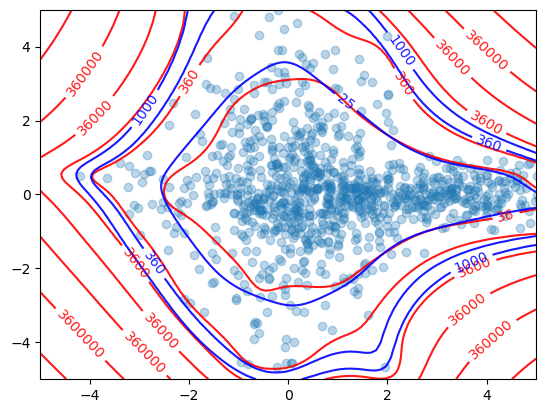

In [14]:
plt.xlim(-5, 5)
plt.ylim(-5, 5)

plt.scatter(*z.T, alpha=.3)

p.plot(plt.gca(), colors='red')

plot_contours(pave, plt.gca(), colors='blue', levels=[25., 360., 1000.])

In [15]:
pr(z).mean()

np.float64(12.060104102764507)

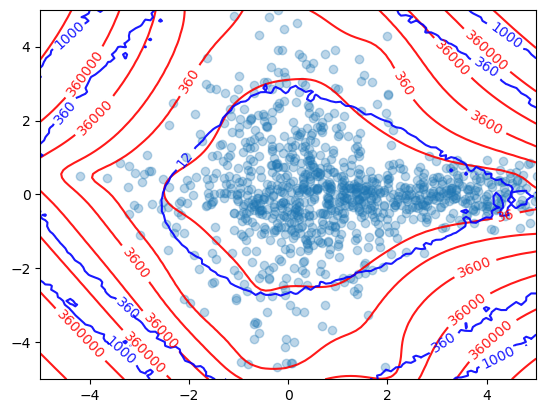

In [16]:
plt.xlim(-5, 5)
plt.ylim(-5, 5)

plt.scatter(*z.T, alpha=.3)

p.plot(plt.gca(), colors='red')

plot_contours(pr, plt.gca(), colors='blue', levels=[12., 360., 1000.])

In [286]:
p(z).mean()

np.float64(35.999999999999986)

In [33]:
z = np.random.randn(10_000, 10)

p = CDPolynomial(z, degree=5, verbose=True)

Data monomials shape: (10000, 3003)
Moment matrix cond num: 2.153271e+05
Empirical mean of CD poly: 3003.0


In [56]:
pnyst = CDNyst(z, 5, 100)

In [62]:
z_test = np.full((1, 10), 2)
%time p(z_test)

CPU times: user 32.9 s, sys: 1.21 s, total: 34.1 s
Wall time: 4.9 s


array([3367831.87754361])

In [66]:
print(pnyst(z).mean())
%time pnyst(z_test)

100.00000000000003
CPU times: user 583 μs, sys: 70 μs, total: 653 μs
Wall time: 661 μs


array([6451.99550099])

## Subsampling by CD poly values

In [240]:
n = 1000
d = 3
n_comp = 40

z = np.random.randn(n, 2)

In [241]:
p = CDPolynomial(z, degree=d, verbose=True)

Data monomials shape: (1000, 10)
Moment matrix cond num: 6.058851e+01
Empirical mean of CD poly: 10.000000000000002


In [242]:
pfeat = PolynomialFeatures(degree=d)

idx = p(z).argsort()[-n_comp:]
z_sub = z[idx]

X = pfeat.fit_transform(z)
X_sub = X[idx]

In [270]:
M_sub = (X_sub.T @ X_sub) / n_comp

def p_sub(x):
    v = pfeat.transform(x)
    return np.einsum('bi,ij,bj->b', v, np.linalg.inv(M_sub), v)

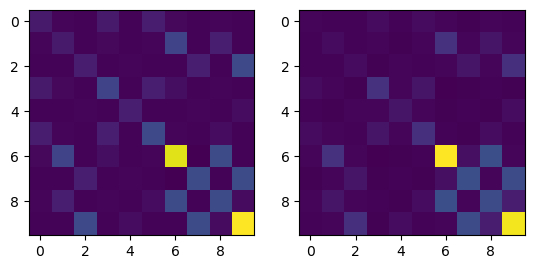

In [271]:
fig, ax = plt.subplots(ncols=2)
ax[0].imshow(p.moments)
ax[1].imshow(M_sub)

(array([306., 343., 153.,  72.,  50.,  41.,  18.,   9.,   5.,   3.]),
 array([0.69802766, 1.20928652, 1.72054539, 2.23180425, 2.74306311,
        3.25432198, 3.76558084, 4.2768397 , 4.78809857, 5.29935743,
        5.81061629]),
 <BarContainer object of 10 artists>)

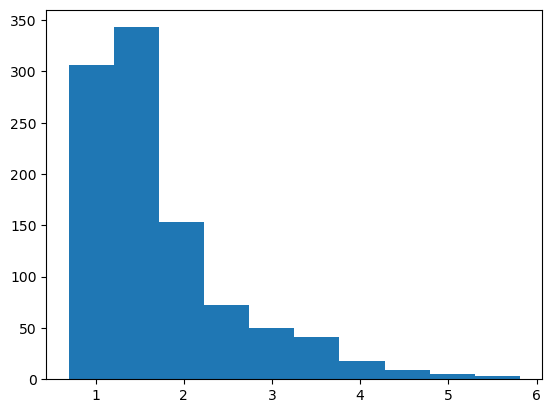

In [275]:
plt.hist(np.log(p(z)))

In [272]:
p_sub(z).mean()

np.float64(32.42213718161217)

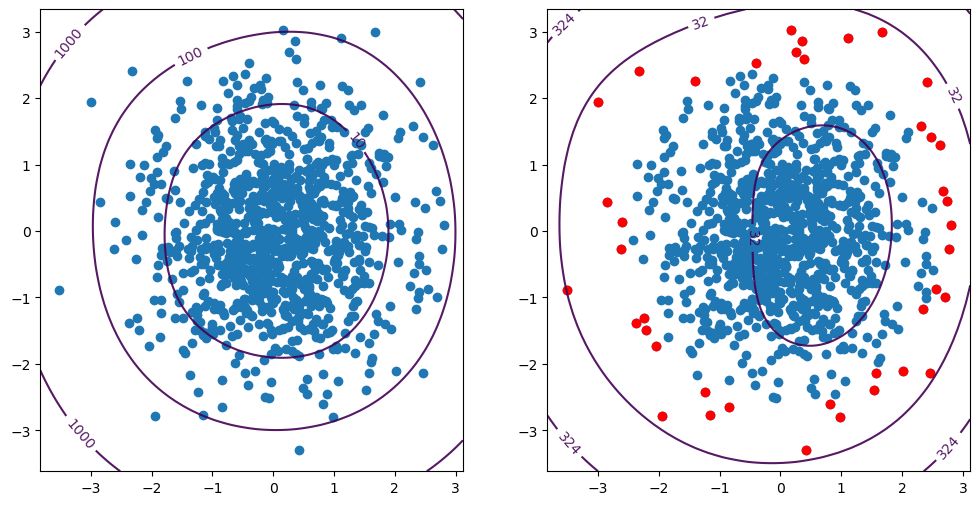

In [273]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

ax[0].scatter(*z.T)
p.plot(ax[0])

ax[1].scatter(*z.T)
ax[1].scatter(*z_sub.T, color='red')
levels = [p_sub(z).mean() * 10 ** i for i in range(5)]
plot_contours(p_sub, ax[1], levels=levels)
